In [ ]:
import os
import re
import pickle
import warnings
import time
from collections import defaultdict
from difflib import get_close_matches

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
%matplotlib inline
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Download NLTK data (run once)
for pkg in ['punkt', 'stopwords', 'wordnet', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

print('✅ All imports successful!')

✅ All imports successful!


In [29]:
DATA_DIR = '../data/raw/'

data       = pd.read_csv(DATA_DIR + 'data.csv')
genre_data = pd.read_csv(DATA_DIR + 'data_by_genres.csv')
year_data  = pd.read_csv(DATA_DIR + 'data_by_year.csv')

lyrics_raw = pd.read_csv(DATA_DIR + 'spotify_songs.csv')

print('=' * 55)
print('DATASET SUMMARY')
print('=' * 55)
print(f'  Main audio data   : {data.shape[0]:>7,} songs  × {data.shape[1]} columns')
print(f'  Genre aggregates  : {genre_data.shape[0]:>7,} genres × {genre_data.shape[1]} columns')
print(f'  Year aggregates   : {year_data.shape[0]:>7,} years  × {year_data.shape[1]} columns')
print(f'  Lyrics dataset    : {lyrics_raw.shape[0]:>7,} songs  × {lyrics_raw.shape[1]} columns')
print()
print('Lyrics dataset columns:', lyrics_raw.columns.tolist())

DATASET SUMMARY
  Main audio data   : 170,653 songs  × 19 columns
  Genre aggregates  :   2,973 genres × 14 columns
  Year aggregates   :     100 years  × 14 columns
  Lyrics dataset    :  18,454 songs  × 25 columns

Lyrics dataset columns: ['track_id', 'track_name', 'track_artist', 'lyrics', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'language']


In [3]:
print('Clustering genres...')
cluster_pipeline = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=10, random_state=42, n_init=10)
)
genre_data['cluster'] = cluster_pipeline.fit_predict(
    genre_data.select_dtypes(include=[np.number])
)
print(f'  ✅ Genre clustering done — 10 clusters on {len(genre_data)} genres')

Clustering genres...
  ✅ Genre clustering done — 10 clusters on 2973 genres


In [4]:
print('Running t-SNE on genres (takes ~30s)...')
tsne_pipeline = make_pipeline(
    StandardScaler(),
    TSNE(n_components=2, verbose=0, random_state=42)
)
projection = pd.DataFrame(
    tsne_pipeline.fit_transform(genre_data.select_dtypes(include=[np.number])),
    columns=['x', 'y']
)
projection['genres']  = genre_data['genres']
projection['cluster'] = genre_data['cluster']

fig = px.scatter(
    projection, x='x', y='y', color='cluster',
    hover_data=['genres'],
    title='Genre Clusters (t-SNE)',
    template='plotly_white'
)
fig.show()

Running t-SNE on genres (takes ~30s)...


In [5]:
AUDIO_FEATURES = [
    'valence', 'year', 'acousticness', 'danceability', 'duration_ms',
    'energy', 'explicit', 'instrumentalness', 'key', 'liveness',
    'loudness', 'mode', 'popularity', 'speechiness', 'tempo'
]
available_features = [f for f in AUDIO_FEATURES if f in data.columns]
print(f'Using {len(available_features)} audio features for song clustering')

song_cluster_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=20, random_state=42, n_init=10, verbose=False))
])
X = data[available_features]
song_cluster_pipeline.fit(X)
data['cluster_label'] = song_cluster_pipeline.predict(X)
print('✅ Song clustering done — 20 clusters on 170k songs')

Using 15 audio features for song clustering
✅ Song clustering done — 20 clusters on 170k songs


In [6]:
pca_pipeline = Pipeline([('scaler', StandardScaler()), ('PCA', PCA(n_components=2))])
song_embedding = pca_pipeline.fit_transform(X)
song_proj = pd.DataFrame(song_embedding, columns=['x', 'y'])
song_proj['title']   = data['name']
song_proj['cluster'] = data['cluster_label']

fig = px.scatter(
    song_proj.sample(5000), x='x', y='y', color='cluster',
    hover_data=['title'],
    title='Song Clusters — PCA (5000 sample)',
    template='plotly_white'
)
fig.show()

In [7]:
lyrics_clean = lyrics_raw.rename(columns={
    'track_name':   'name',
    'track_artist': 'artist_name',
})

data['_name_key']           = data['name'].str.lower().str.strip()
lyrics_clean['_name_key']   = lyrics_clean['name'].str.lower().str.strip()

data['_artist_key'] = (
    data['artists']
    .str.replace(r"[\[\]']", '', regex=True)
    .str.split(',').str[0]
    .str.lower().str.strip()
)
lyrics_clean['_artist_key'] = lyrics_clean['artist_name'].str.lower().str.strip()

merged = pd.merge(
    data,
    lyrics_clean[['_name_key', '_artist_key', 'lyrics', 'language']],
    on=['_name_key', '_artist_key'],
    how='inner'
)
print(f"Merge 1 (name + artist): {len(merged)} songs")

if len(merged) < 500:
    print("Low match — trying name-only merge...")
    merged = pd.merge(
        data,
        lyrics_clean[['_name_key', 'lyrics', 'language']],
        on='_name_key',
        how='inner'
    )
    print(f"Merge 2 (name only): {len(merged)} songs")

merged = merged.drop(columns=['_name_key', '_artist_key'], errors='ignore')
data   = data.drop(columns=['_name_key', '_artist_key'], errors='ignore')
merged = merged.dropna(subset=['lyrics'])
merged = merged[merged['lyrics'].str.strip() != ''].reset_index(drop=True)

print(f"\n✅ Final: {len(merged):,} songs with audio + lyrics")
print(f"   Match rate: {len(merged)/len(data)*100:.1f}%")
merged[['name', 'artists', 'year', 'lyrics']].head(3)

Merge 1 (name + artist): 10994 songs

✅ Final: 10,960 songs with audio + lyrics
   Match rate: 6.4%


,name,artists,year,lyrics
0,Ain't No Sunshine,['Bill Withers'],1942,Ain't no sunshine when she's gone It's not war...
1,The Devil Went Down to Georgia,['The Charlie Daniels Band'],1954,The Devil went down to Georgia. He was lookin'...
2,Long Tall Sally (The Thing),['Little Richard'],1957,Going to tell Aunt Mary about Uncle John He cl...


In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

music_noise = {
    'verse', 'chorus', 'bridge', 'intro', 'outro', 'hook',
    'oh', 'ah', 'yeah', 'ooh', 'la', 'na', 'da', 'hey',
    'hmm', 'uh', 'woah', 'gonna', 'wanna', 'gotta', 'em', 'ima'
}
stop_words = stop_words.union(music_noise)


def preprocess_lyrics(text):
    """
    NLP preprocessing pipeline:
      1. Lowercase
      2. Remove special characters / numbers
      3. Tokenize
      4. Remove stopwords + music noise
      5. Lemmatize  (loved → love, running → run)
      6. Drop tokens shorter than 3 characters
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


print('Preprocessing lyrics... (1–2 minutes)')
t0 = time.time()
merged['lyrics_clean'] = merged['lyrics'].apply(preprocess_lyrics)
print(f'✅ Done in {time.time()-t0:.1f}s')

idx = 0
print(f'\nSong: {merged["name"].iloc[idx]}')
print('\n[BEFORE]:', merged['lyrics'].iloc[idx][:200])
print('\n[AFTER] :', merged['lyrics_clean'].iloc[idx][:200])

Preprocessing lyrics... (1–2 minutes)
✅ Done in 11.3s

Song: Ain't No Sunshine

[BEFORE]: Ain't no sunshine when she's gone It's not warm when she's away Ain't no sunshine when she's gone And she's always gone too long anytime she goes away Wonder this time where she's gone Wonder if she's

[AFTER] : sunshine gone warm away sunshine gone always gone long anytime go away wonder time gone wonder gone stay sunshine gone house home anytime go away know know know know know know know know know know know


In [28]:
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    ngram_range=(1, 2),
    token_pattern=r'\b[a-z]{3,}\b',
    sublinear_tf=True
)

print('Building TF-IDF matrix...')
tfidf_matrix = tfidf.fit_transform(merged['lyrics_clean'])
print(f'✅ TF-IDF matrix: {tfidf_matrix.shape[0]:,} songs × {tfidf_matrix.shape[1]:,} lyric features')

feature_names   = tfidf.get_feature_names_out()
sample          = merged.iloc[0]
scores          = tfidf_matrix[0].toarray()[0]
top_idx         = scores.argsort()[-10:][::-1]

print(f'\nTop lyric keywords for: "{sample["name"]}"')
for i in top_idx:
    if scores[i] > 0:
        print(f'  {feature_names[i]:<25} {scores[i]:.4f}')

Building TF-IDF matrix...
✅ TF-IDF matrix: 10,960 songs × 5,000 lyric features

Top lyric keywords for: "Ain't No Sunshine"
  anytime                   0.4368
  know know                 0.3938
  sunshine                  0.3925
  gone                      0.2579
  ought                     0.2175
  away know                 0.2067
  wonder                    0.2050
  away                      0.1941
  darkness                  0.1896
  house                     0.1853


In [10]:
SIMILARITY_FEATURES = [
    'valence', 'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness', 'tempo'
]
sim_features = [f for f in SIMILARITY_FEATURES if f in merged.columns]

scaler       = StandardScaler()
audio_matrix = scaler.fit_transform(merged[sim_features])

print(f'✅ Audio matrix ready: {audio_matrix.shape[0]:,} songs × {audio_matrix.shape[1]} features')

✅ Audio matrix ready: 10,960 songs × 9 features


In [11]:
def find_song_in_dataset(name, year, spotify_data, year_tolerance=2):
    match = spotify_data[
        (spotify_data['name'].str.lower() == name.lower()) &
        (spotify_data['year'] == year)
    ]
    if len(match) > 0:
        return match.iloc[0]
    year_matches = spotify_data[
        (spotify_data['year'] >= year - year_tolerance) &
        (spotify_data['year'] <= year + year_tolerance)
    ]
    if len(year_matches) > 0:
        close = get_close_matches(name, year_matches['name'].tolist(), n=1, cutoff=0.6)
        if close:
            row = year_matches[year_matches['name'] == close[0]]
            if len(row) > 0:
                print(f"  Fuzzy match: '{close[0]}' ({row.iloc[0]['year']})")
                return row.iloc[0]
    return None


def get_song_data(song, spotify_data):
    try:
        match = spotify_data[
            (spotify_data['name'] == song['name']) &
            (spotify_data['year'] == song['year'])
        ]
        if len(match) > 0:
            return match.iloc[0]
        return find_song_in_dataset(song['name'], song['year'], spotify_data)
    except Exception as e:
        print(f"Error: {e}")
        return None


def get_mean_vector(song_list, spotify_data):
    song_vectors, valid_songs = [], []
    for song in song_list:
        song_data = get_song_data(song, spotify_data)
        if song_data is None:
            print(f"  Warning: '{song['name']}' not found")
            continue
        song_vectors.append(song_data[available_features].values)
        valid_songs.append(song['name'])
    if not song_vectors:
        return None
    print(f"  Using: {valid_songs}")
    return np.mean(np.array(song_vectors), axis=0)


def flatten_dict_list(dict_list):
    if not dict_list:
        return defaultdict(list)
    result = defaultdict(list)
    for d in dict_list:
        for k, v in d.items():
            result[k].append(v)
    return result


def recommend_songs_phase1(song_list, spotify_data, n_songs=10):
    """Phase 1: Audio-only recommendation (original engine)"""
    song_dict   = flatten_dict_list(song_list)
    song_center = get_mean_vector(song_list, spotify_data)
    if song_center is None:
        return []
    scaler_p1     = song_cluster_pipeline.named_steps['scaler']
    scaled_data   = scaler_p1.transform(spotify_data[available_features])
    scaled_center = scaler_p1.transform(song_center.reshape(1, -1))
    distances     = cdist(scaled_center, scaled_data, 'cosine')
    index         = list(np.argsort(distances)[:, :n_songs + len(song_list)][0])
    rec_songs     = spotify_data.iloc[index]
    if song_dict['name']:
        rec_songs = rec_songs[~rec_songs['name'].isin(song_dict['name'])]
    return rec_songs[['name', 'year', 'artists']].head(n_songs).to_dict(orient='records')


print('✅ Phase 1 engine loaded')

✅ Phase 1 engine loaded


In [12]:
def get_song_index(song_name, data):
    exact = data[data['name'].str.lower() == song_name.lower()]
    if len(exact) > 0:
        return exact.sort_values('popularity', ascending=False).index[0]
    partial = data[data['name'].str.lower().str.contains(song_name.lower(), na=False)]
    if len(partial) > 0:
        return partial.sort_values('popularity', ascending=False).index[0]
    return None


def hybrid_recommend(song_name, data, audio_mat, lyric_mat,
                     audio_weight=0.5, lyric_weight=0.5, n=10):
    idx = get_song_index(song_name, data)
    if idx is None:
        print(f'❌ Song not found: "{song_name}"')
        return None

    found = data.loc[idx]
    print(f'🎵 Found: "{found["name"]}" by {found["artists"]} ({found["year"]})')

    audio_sim = cosine_similarity(audio_mat[idx].reshape(1, -1), audio_mat)[0]
    lyric_sim = cosine_similarity(lyric_mat[idx], lyric_mat)[0]

    hybrid_score = (audio_weight * audio_sim) + (lyric_weight * lyric_sim)

    result = data.copy()
    result['audio_sim']    = audio_sim
    result['lyric_sim']    = lyric_sim
    result['hybrid_score'] = hybrid_score

    result = result.drop(index=idx)

    result = result.sort_values('hybrid_score', ascending=False)
    result = result.drop_duplicates(subset=['name'], keep='first')

    input_name_lower = found['name'].lower()
    result = result[~result['name'].str.lower().str.startswith(input_name_lower + ' -')]

    cols = ['name', 'artists', 'year', 'popularity', 'audio_sim', 'lyric_sim', 'hybrid_score']
    return result[cols].head(n)


def search_songs(keyword, data=merged, limit=10):
    matches = data[data['name'].str.contains(keyword, case=False, na=False)]
    if len(matches) > 0:
        print(f'Found {len(matches)} songs containing "{keyword}":')
        return matches[['name', 'artists', 'year', 'popularity']].head(limit)
    print(f'No songs found containing "{keyword}"')
    return pd.DataFrame()


print('✅ Hybrid recommendation engine ready!')

✅ Hybrid recommendation engine ready!


In [26]:
TEST_SONG = 'Love me like you do'
TEST_YEAR = 2015

print('=' * 65)
print(f'PHASE 1 — Audio-only  (original engine, 170k dataset)')
print('=' * 65)
p1_results = recommend_songs_phase1([{'name': TEST_SONG, 'year': TEST_YEAR}], data, n_songs=5)
for i, s in enumerate(p1_results, 1):
    print(f'  {i}. {s["name"]} — {s["artists"]} ({s["year"]})')

print()
print('=' * 65)
print(f'PHASE 2 — Hybrid (audio 50% + lyrics 50%)')
print('=' * 65)
p2_results = hybrid_recommend(
    TEST_SONG, merged, audio_matrix, tfidf_matrix,
    audio_weight=0.5, lyric_weight=0.5, n=5
)
if p2_results is not None:
    pd.set_option('display.max_colwidth', 40)
    pd.set_option('display.width', 200)
    print(p2_results[['name', 'artists', 'year', 'audio_sim', 'lyric_sim', 'hybrid_score']].to_string(index=False))

PHASE 1 — Audio-only  (original engine, 170k dataset)
  Using: ['Love me like you do']
  1. Love Me Like You Do — ['Brooklyn Duo'] (2015)
  2. Enterprising Young Men — ['Michael Giacchino'] (2009)
  3. Define Dancing — ['Thomas Newman'] (2008)
  4. Fairytale of New York — ['Kevin Duncan'] (2013)
  5. Beneath The Moonlit Sky — ['Dave Koz', 'David Benoit'] (2001)

PHASE 2 — Hybrid (audio 50% + lyrics 50%)
🎵 Found: "Love Me Like You Do" by ['Ellie Goulding'] (2018)
                                                      name         artists  year  audio_sim  lyric_sim  hybrid_score
                                       If You Leave Me Now     ['Chicago']  1976   0.826003   0.228291      0.527147
She Makes Me (Stormtrooper In Stilettos) - Remastered 2011       ['Queen']  1974   0.922223   0.104614      0.513419
                                      The Drugs Don't Work   ['The Verve']  1997   0.915195   0.096619      0.505907
                                                Let Her Go   ['Pa

In [27]:
print('Lyrics-heavy mode (audio=0.2, lyrics=0.8):')
print('-' * 50)
lyrics_focused = hybrid_recommend(
    TEST_SONG, merged, audio_matrix, tfidf_matrix,
    audio_weight=0.2, lyric_weight=0.8, n=5
)
if lyrics_focused is not None:
    print(lyrics_focused[['name', 'artists', 'year', 'hybrid_score']].to_string(index=False))

Lyrics-heavy mode (audio=0.2, lyrics=0.8):
--------------------------------------------------
🎵 Found: "Love Me Like You Do" by ['Ellie Goulding'] (2018)
                    name                                            artists  year  hybrid_score
                 Hold Up                                        ['Beyoncé']  2016      0.557935
      Love Him Like I Do ['Deitrick Haddon', 'Ruben Studdard', 'Mary Mary']  2008      0.493080
            LIKE I WOULD                                           ['ZAYN']  2016      0.433715
Complexion (A Zulu Love)                      ['Kendrick Lamar', 'Rapsody']  2015      0.412647
           Hurts So Good                                       ['Astrid S']  2016      0.393608


In [15]:
search_songs('love')

Found 575 songs containing "love":


,name,artists,year,popularity
29,You Can't Hurry Love,['The Supremes'],1966,73
32,When a Man Loves a Woman,['Percy Sledge'],1966,67
60,What the World Needs Now(Is Love),['Dionne Warwick'],1967,59
61,I Never Loved a Man (The Way I Love You),['Aretha Franklin'],1967,52
77,"Hello, I Love You",['The Doors'],1968,62
101,Whole Lotta Love - 1990 Remaster,['Led Zeppelin'],1969,77
211,I'd Love to Change the World - 2004 Remaster,['Ten Years After'],1971,61
262,I'd Love You to Want Me,['Lobo'],1972,66
264,Satellite of Love,['Lou Reed'],1972,62
326,I'll Have To Say I Love You In A Song,['Jim Croce'],1973,62


EVALUATION METRICS
🎵 Found: "Despacito" by ['Luis Fonsi', 'Daddy Yankee'] (2019)
  Using: ['Despacito']
🎵 Found: "Shape of You" by ['Ed Sheeran'] (2017)
  Using: ['Shape of You']
🎵 Found: "Blinding Lights" by ['The Weeknd'] (2020)
  Using: ['Blinding Lights']
🎵 Found: "Bohemian Rhapsody - Remastered 2011" by ['Queen'] (1975)
  Using: ['Bohemian Rhapsody']

Per-song metrics:
             Song  Avg Audio Sim  Avg Lyric Sim  Avg Hybrid Score  P1 Diversity  P2 Diversity
        Despacito         0.9281         0.3980            0.6631        0.2545        0.1246
     Shape of You         0.9360         0.1517            0.5438        0.4868        0.1438
  Blinding Lights         0.9292         0.1026            0.5159        0.1740        0.1197
Bohemian Rhapsody         0.8851         0.2570            0.5710        0.0000        0.2635

Average Intra-list Diversity:
  Phase 1 (audio only) : 0.2288
  Phase 2 (hybrid)     : 0.1629

Catalog Coverage (Phase 2): 0.36%


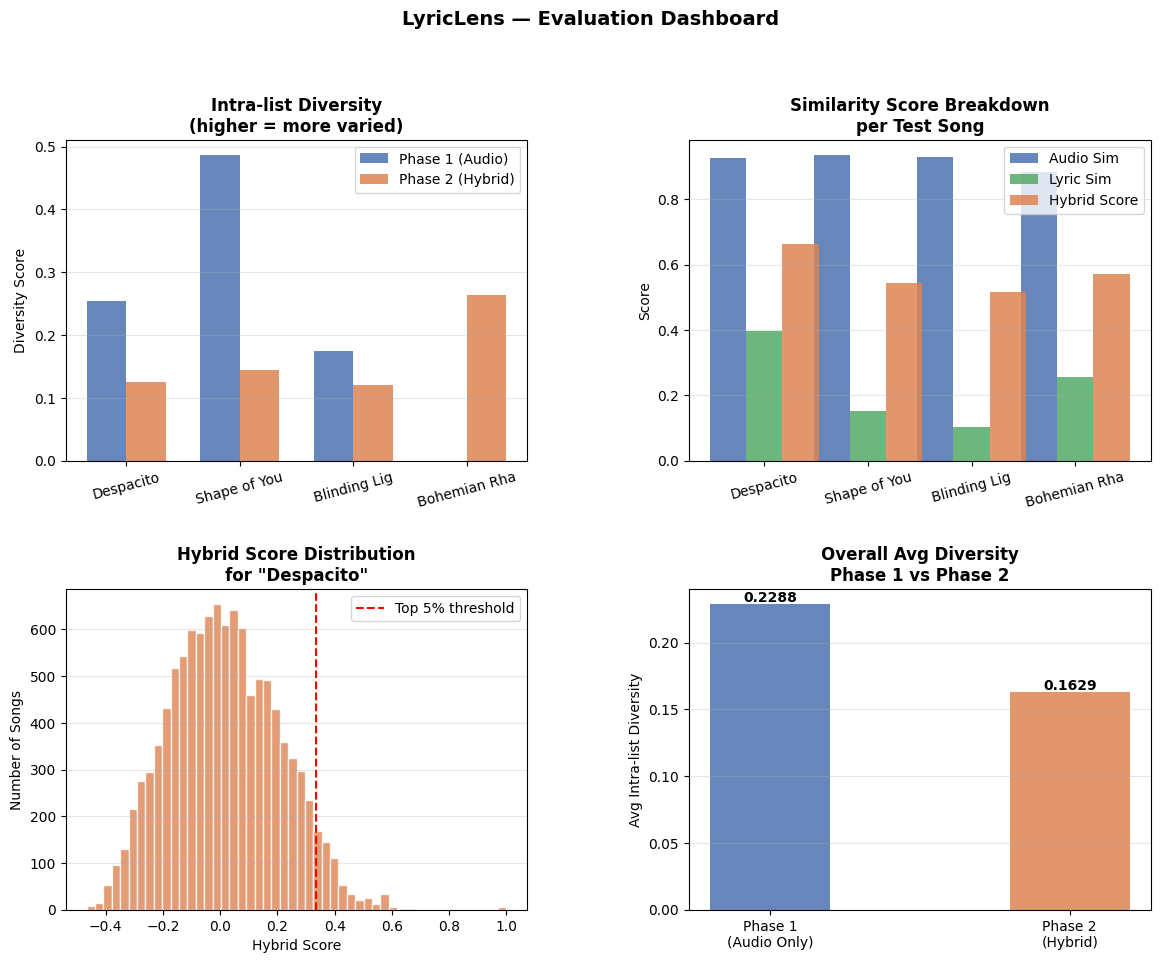


✅ Evaluation dashboard saved to assets/


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

TEST_SONGS = ['Despacito', 'Shape of You', 'Blinding Lights', 'Bohemian Rhapsody']

def intra_list_diversity(rec_df, audio_mat, data):
    """Higher = recommendations are more diverse from each other"""
    indices = []
    for name in rec_df['name']:
        idx = get_song_index(name, data)
        if idx is not None:
            indices.append(idx)
    if len(indices) < 2:
        return 0.0
    vecs = audio_mat[indices]
    sim_matrix = cosine_similarity(vecs)
    n = len(indices)
    total = sum(1 - sim_matrix[i][j]
                for i in range(n) for j in range(n) if i != j)
    return total / (n * (n - 1))


def catalog_coverage(all_recommendations, total_songs):
    """What % of the catalog appears in recommendations"""
    unique_recommended = set()
    for rec_list in all_recommendations:
        if rec_list is not None:
            unique_recommended.update(rec_list['name'].tolist())
    return len(unique_recommended) / total_songs * 100


print('='*65)
print('EVALUATION METRICS')
print('='*65)

p1_diversity_scores, p2_diversity_scores = [], []
p1_all_recs, p2_all_recs = [], []

eval_rows = []
for song in TEST_SONGS:
    idx = get_song_index(song, merged)
    if idx is None:
        print(f'  Skipping "{song}" — not in merged dataset')
        continue

    p2 = hybrid_recommend(song, merged, audio_matrix, tfidf_matrix,
                          audio_weight=0.5, lyric_weight=0.5, n=10)
    if p2 is None:
        continue

    p2_div = intra_list_diversity(p2, audio_matrix, merged)
    p1_recs_names = recommend_songs_phase1(
        [{'name': song, 'year': merged.loc[idx, 'year']}], data, n_songs=10
    )

    p1_df = pd.DataFrame(p1_recs_names)
    if len(p1_df) > 0:
        p1_div = intra_list_diversity(p1_df, audio_matrix, merged)
        p1_diversity_scores.append(p1_div)
        p1_all_recs.append(p1_df)
    else:
        p1_div = 0

    p2_diversity_scores.append(p2_div)
    p2_all_recs.append(p2)

    avg_lyric_sim  = p2['lyric_sim'].mean()
    avg_audio_sim  = p2['audio_sim'].mean()
    avg_hybrid     = p2['hybrid_score'].mean()

    eval_rows.append({
        'Song': song,
        'Avg Audio Sim': round(avg_audio_sim, 4),
        'Avg Lyric Sim': round(avg_lyric_sim, 4),
        'Avg Hybrid Score': round(avg_hybrid, 4),
        'P1 Diversity': round(p1_div, 4),
        'P2 Diversity': round(p2_div, 4),
    })

eval_df = pd.DataFrame(eval_rows)
print('\nPer-song metrics:')
print(eval_df.to_string(index=False))

print(f'\nAverage Intra-list Diversity:')
print(f'  Phase 1 (audio only) : {np.mean(p1_diversity_scores):.4f}')
print(f'  Phase 2 (hybrid)     : {np.mean(p2_diversity_scores):.4f}')

p2_coverage = catalog_coverage(p2_all_recs, len(merged))
print(f'\nCatalog Coverage (Phase 2): {p2_coverage:.2f}%')


fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
x   = np.arange(len(eval_df))
w   = 0.35
ax1.bar(x - w/2, eval_df['P1 Diversity'], w, label='Phase 1 (Audio)', color='#4C72B0', alpha=0.85)
ax1.bar(x + w/2, eval_df['P2 Diversity'], w, label='Phase 2 (Hybrid)', color='#DD8452', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels([s[:12] for s in eval_df['Song']], rotation=15)
ax1.set_title('Intra-list Diversity\n(higher = more varied)', fontweight='bold')
ax1.set_ylabel('Diversity Score')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
x2  = np.arange(len(eval_df))
ax2.bar(x2 - w, eval_df['Avg Audio Sim'],   w, label='Audio Sim',  color='#4C72B0', alpha=0.85)
ax2.bar(x2,     eval_df['Avg Lyric Sim'],   w, label='Lyric Sim',  color='#55A868', alpha=0.85)
ax2.bar(x2 + w, eval_df['Avg Hybrid Score'],w, label='Hybrid Score',color='#DD8452', alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels([s[:12] for s in eval_df['Song']], rotation=15)
ax2.set_title('Similarity Score Breakdown\nper Test Song', fontweight='bold')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
sample_song = TEST_SONGS[0]
idx_s = get_song_index(sample_song, merged)
if idx_s is not None:
    audio_s  = cosine_similarity(audio_matrix[idx_s].reshape(1,-1), audio_matrix)[0]
    lyric_s  = cosine_similarity(tfidf_matrix[idx_s], tfidf_matrix)[0]
    hybrid_s = 0.5 * audio_s + 0.5 * lyric_s
    ax3.hist(hybrid_s, bins=50, color='#DD8452', alpha=0.8, edgecolor='white')
    ax3.axvline(np.percentile(hybrid_s, 95), color='red', linestyle='--',
                label='Top 5% threshold')
    ax3.set_title(f'Hybrid Score Distribution\nfor "{sample_song}"', fontweight='bold')
    ax3.set_xlabel('Hybrid Score')
    ax3.set_ylabel('Number of Songs')
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
phases = ['Phase 1\n(Audio Only)', 'Phase 2\n(Hybrid)']
avgs   = [np.mean(p1_diversity_scores), np.mean(p2_diversity_scores)]
colors = ['#4C72B0', '#DD8452']
bars   = ax4.bar(phases, avgs, color=colors, alpha=0.85, width=0.4)
for bar, val in zip(bars, avgs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontweight='bold')
ax4.set_title('Overall Avg Diversity\nPhase 1 vs Phase 2', fontweight='bold')
ax4.set_ylabel('Avg Intra-list Diversity')
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('LyricLens — Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../assets/evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Evaluation dashboard saved to assets/')

In [17]:
merged.to_csv('../data/processed/lyriclens_merged.csv', index=False)

with open('../models/lyriclens_models.pkl', 'wb') as f:
    pickle.dump({
        'tfidf':        tfidf,
        'tfidf_matrix': tfidf_matrix,
        'audio_matrix': audio_matrix,
        'scaler':       scaler,
        'features':     sim_features,
        'merged_index': merged[['name', 'artists', 'year']].to_dict()
    }, f)

print('✅ Saved: data/processed/lyriclens_merged.csv')
print('✅ Saved: models/lyriclens_models.pkl')

✅ Saved: data/processed/lyriclens_merged.csv
✅ Saved: models/lyriclens_models.pkl
